author: Xu Chen, 2022/4/20， xuchen21@mails.ucas.ac.cn

In [ ]:
# import h5py
import numpy as np
import matplotlib.pyplot as plt
from hifast.ripple.util import *
from copy import deepcopy
from hifast.ripple.markRFI import *

In [ ]:
# 这里是已经去过基线的-bld.hdf5文件
subname = '/data/inspur_disk01/userdir/xuc/FAST/G15/new_22/drift7/sub/G15_7_arcdrift-M12_W-20210809-specs_T-bld.hdf5'
sub = Read_hdf5(Args(subname))

# data

In [ ]:
# 合并偏振
data = sub.get_data(polar='average')
freq = sub.freq

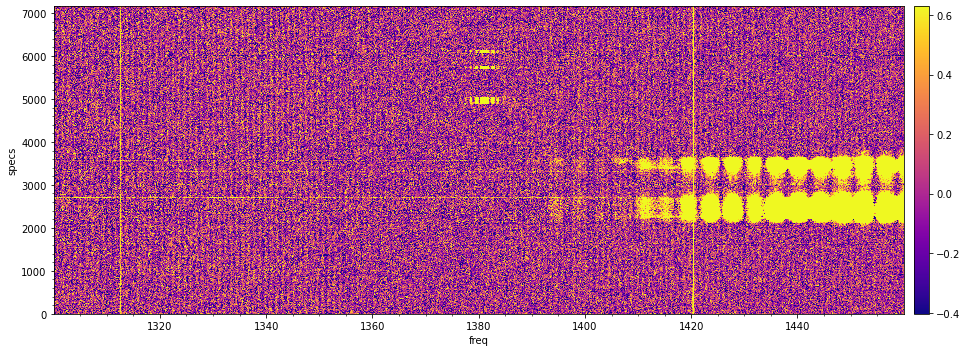

In [ ]:
sub.plot_waterfall(data,per_vmin_max=.90,figsize=(15,5),cmap = 'plasma')

# RFI类型

rfi.py处理的优先级顺序：
* `lf`: Long-freq time RFI. 类似于上图中频率范围很大的时域RFI，可能是卫星
* `sf`: Short-freq time RFI. 类似于上图中1380MHz的频率范围很小的时域RFI，主要是GPS
* `tr`: Time domain continuous RFI. 时域上连续出现的RFI。最早为8MHz的RFI设计，可能标记不全`nr`
* `nr`: Narrowband single channel RFI. 单通道频域RFI，如上图1312MHz的竖线
* `pdr`: Period 8 MHZ RFI. 间隔8MHz的高斯型RFI，如后面的图，来自于压缩机，2021年7月已消除
* `pr`: Polarized RFI. 偏振上差异过大的RFI

下面针对部分参数进行简单说明。

## lf

很强的长频率时域RFI

| --lf para | function para | default | 建议 |
|---|---|---|---| 
| --lf_frange | frange | [1400,1500] | 大范围频率，例如[1400,1460]。这里会自动避开银河系[1419,1422] |
| --lf_mean_times | mean_times | 2 | 根据图片确定阈值倍数|
| --lf_diff_times | diff_times | 0 | 由于是平缓的边界，不需要边缘陡峭的约束条件，直接设为0|
| --lf_rfi_last | rfi_width_lim | [50, inf] |一般宽度300～500以上，如果刚好在边缘有些难搞，可能只有50甚至更小|
| --lf_ext | ext_add | 50 | 选定区域后，扩展边缘。由于RFI很大，谱线方向多扔了一些|
| --lf_mask_rms_times| mask_rms_times | -1 | 如果是-1，会标记整条谱线；如果为0，只标记存在RFI谱线的frange区域(不过注意如果frange区域占比过大，余下的部分做FFT去驻波效果可能变差)；如果大于0，则只标记存在RFI谱线的大于RMS一个倍数阈值的部分，频率方向用ext_add扩展边缘。

In [ ]:
# 防止lf和sf标记银河系
mw_frange = [1420, 1421]
protect_use = (freq>mw_frange[0])&(freq<mw_frange[1])
Tt = deepcopy(data)
Tt[:,protect_use] = np.nan

rfi starts at tn = [2107], ends in tn = [3752]
After extension, rfi starts at tn = [2007], ends in tn = [3852]
Median value is 0.01593729853630066. mean_thr = 0.03187459707260132. diff_thr = 0.0
INFO: Looking for long-freq time RFI ... [hifast.ripple.markRFI]
Mask the whole spec with rfi :(
Found :D
Finish


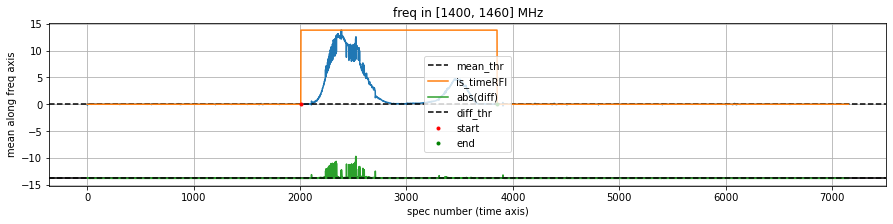

In [ ]:
l_rfi = mask_time_rfi(Tt,freq, rtype = 'long-freq',frange =[1400,1460],mean_times = 2,diff_times = 0,
                      ext_add=100,rfi_width_lim = 50,plot = True)

蓝色线是frange =[1400,1460]内所有谱线沿频率方向的平均；绿色线是后一个通道减前一个通道取绝对值，`sf`会需要此作为第二个阈值。画图时绿线有向下平移一个蓝线的最大值，为了把它们画在一个图里。虚线为相应的阈值。

可以检查mask区域边缘的谱线平均后是否还有大RFI。

In [ ]:
Tt[l_rfi] = np.nan

<ipython-input-7-9b838768c78b>:4: RuntimeWarning: Mean of empty slice
  plt.plot(freq,np.nanmean(Tt[tn:tn+100,:],axis = 0))


(-0.2, 0.5)

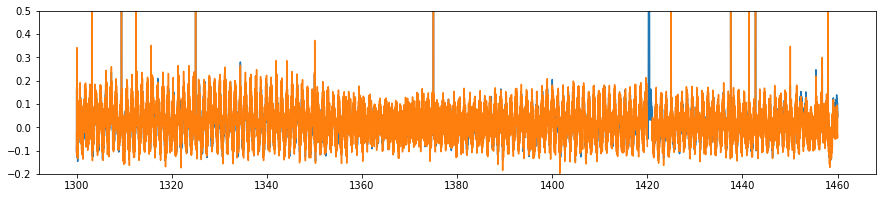

In [ ]:
tn = 3797
plt.figure(figsize=(15,3))
plt.plot(freq,np.mean(data[tn:tn+100,:],axis = 0))
plt.plot(freq,np.nanmean(Tt[tn:tn+100,:],axis = 0))
plt.ylim(-.2,.5)

## sf

短横条样子的时域RFI

| --sf para | function para | default | 建议 |
|---|---|---|---|
| --sf_frange | frange | [1370, 1390] | 一般是1380mhz附近有这种rfi，但不全是。推荐设置`--sf_frange_step` |
| --sf_frange_step | frange | 30 | 从起始频率开始循环的步长。每个区间中重叠一半的频率，优先使用 |
| --sf_file | frange | | 存储(n,2)维频率区间的npy文件，不常用 |
| --sf_mean_times | mean_times | 3 | 根据下图虚线决定阈值是中值的多少倍，这里我使用的3倍 |
| --sf_diff_times | diff_times | >0 |有时这种rfi边界平缓，一般比较陡峭，可以试验看看 |
| --sf_rfi_last | rfi_width_lim | [10, inf] |根据rfi时域宽度判断，对于下面右边的rfi wide > 10 |
| --sf_ext | ext_add | 0 |一般不用扩展，设为0或1 |
| --sf_mask_rms_times| mask_rms_times | 3 | 这里是一个正数，mask小区间frange内，从rfi峰值向两边以半高全宽扩展，为了防止mask过多，扩展到3倍的RMS停止。|

/home/xuc/.local/lib/python3.9/site-packages/hifast-master-py3.9.egg/hifast/ripple/markRFI.py:677: RuntimeWarning: Mean of empty slice
  pat_mean = np.nanmean(pat_data,axis = 1)


rfi starts at tn = [ 846 4886 5684 6063], ends in tn = [ 867 5030 5757 6135]
Median value is 0.010465193539857864. mean_thr = 0.03139558061957359. diff_thr = 0.10465193539857864
INFO: Looking for short-freq time RFI in [1360, 1390] ... [hifast.ripple.markRFI]
tn = [4885, 5031] mask frange: [1375.28610229 1386.79122925]
tn = [5683, 5758] mask frange: [1375.34332275 1386.84082031]
tn = [6062, 6136] mask frange: [1376.98745728 1384.87625122]
Found :D
Finish


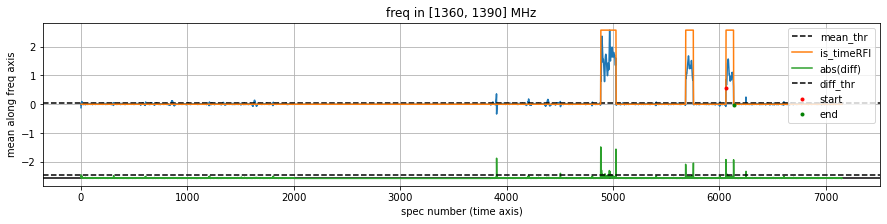

In [ ]:
s_rfi = mask_time_rfi(Tt,freq, rtype = 'short-freq',frange =[1360,1390],mean_times = 3,diff_times = 10,
                      ext_add=0,rfi_width_lim = 20,plot = True,rms_frange=[1390,1400])

有时由于基线的问题，蓝色线的中值可能过于正/负，且不同波束不一样，这时(`lf`和`sf`，`nr`都)可以使用`--lsn_thr_type`(对应到mask_time_rfi函数是`thr_type`)，设为'input_thr'，它会将蓝色线整体移至0附近，之后在原先输入`mean_times`和`diff_times`直接输入固定的阈值即可。

/home/xuc/.local/lib/python3.9/site-packages/hifast-master-py3.9.egg/hifast/ripple/markRFI.py:677: RuntimeWarning: Mean of empty slice
  pat_mean = np.nanmean(pat_data,axis = 1)


rfi starts at tn = [4886 5684 6063], ends in tn = [5030 5757 6135]
Median value is 0.010465193539857864. mean_thr = 0.4. diff_thr = 0.1
INFO: Looking for short-freq time RFI in [1360, 1390] ... [hifast.ripple.markRFI]
tn = [4885, 5031] mask frange: [1375.28610229 1386.79122925]
tn = [5683, 5758] mask frange: [1375.34332275 1386.84082031]
tn = [6062, 6136] mask frange: [1376.98745728 1384.87625122]
Found :D
Finish


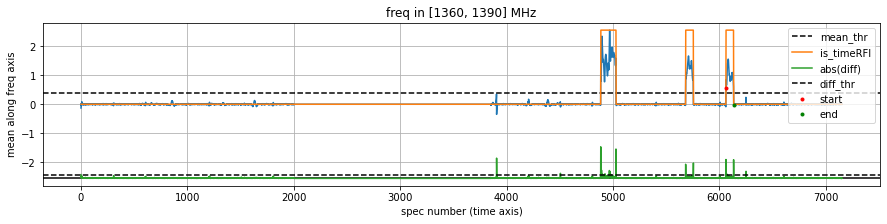

In [ ]:
s_rfi = mask_time_rfi(Tt,freq, rtype = 'short-freq',frange =[1360,1390],mean_times = 0.4,diff_times = 0.1,
                      ext_add=0,rfi_width_lim = 20,plot = True,rms_frange=[1390,1400],
                     thr_type = 'input_thr')

rfis start at ... end in ...表示有哪些谱线满足了rfi_width_lim和大于times倍阈值条件，最后输出的只有3个mask frange，说明最后有三个满足边缘陡峭条件(thr > 10).

In [ ]:
Tt[s_rfi] = np.nan

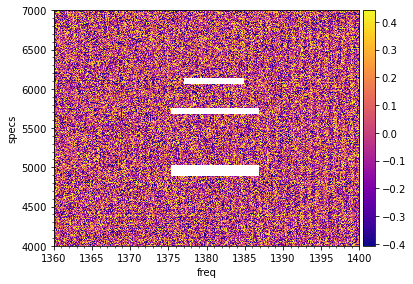

In [ ]:
sub.plot_waterfall(Tt,per_vmin_max=.90,figsize=(6,4),cmap = 'plasma', xylim = (1360,1400,4000,7000))

<ipython-input-12-9fbcf491975f>:4: RuntimeWarning: Mean of empty slice
  plt.plot(freq,np.nanmean(Tt[t1:t2,:],axis = 0))


(1360.0, 1400.0)

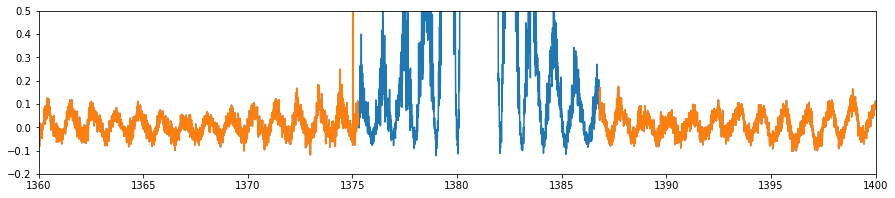

In [ ]:
t1,t2 = 4885, 5030
plt.figure(figsize=(15,3))
plt.plot(freq,np.mean(data[t1:t2,:],axis = 0))
plt.plot(freq,np.nanmean(Tt[t1:t2,:],axis = 0))
plt.ylim(-.2,.5)
plt.xlim(1360,1400)

## tr & pr

这里不演示，只说明参数

`--pr`: 比较两个偏振，如果偏差过大则标记对应channel为RFI。

|--pr para | default | 建议 |
|---|---|---|
|--pr_s_sigma| 5 | 沿时间维度高斯平滑（以pr_s_sigma为sigma）谱线以提高信噪比|
|--pr_times | 6 | 不平滑下两偏振的偏差至少大于等于5倍|
|--pr_times_s | 1 | 平滑下两偏振的偏差至少大于等于1倍|

`--tr`: 找出每条谱线超出噪音的“信号”，然后在沿时间轴比较，如果一个“信号”持续很久(大于--tr_n_continue)，则认为是RFI。不适用于银河系频段。原本为8MHz RFI和单通道RFI设计，但是现在没有8MHz RFI了，nr可以很好地去除单通道RFI，而且--tr_n_continue的设置可能去掉信号，所以默认为False。

|--tr para | default | 建议 |
|---|---|---|
|--tr_s_sigma等 | | 平滑参数
|--tr_times| 6 | 不平滑下至少大于等于5
|--tr_times_s| 1.5| 平滑下大于1.5
|--tr_n_continue| 100 | 一个“信号”持续多少条就标记为rfi，展源要**谨慎**使用

## nr
单通道RFI

| --nr para | function para | default | 建议 |
|---|---|---|---| 
| --nr_mean_times | mean_times | 100 | 根据图片确定阈值倍数 |
| --nr_diff_times | diff_times | 30 | 边缘陡峭的约束条件|
| 内置参数 | rfi_width_lim | [0,2] | 单通道，宽度为1 |
| 内置参数 | ext_add | 1 | 扩展边缘 |
| --nr_mask_rms_times| mask_rms_times | 0 | 如果是0，会标记整个通道；如果大于0，则只标记存在RFI通道的大于RMS一个倍数阈值的部分，时间方向用ext_add扩展边缘。

In [ ]:
T = deepcopy(data)
T[l_rfi|s_rfi] = np.nan

INFO: Looking for long-time narrowband freq RFI ... [hifast.ripple.markRFI]
rfi starts at tn = [ 1641  3279  9833 18025 20702], ends in tn = [ 1642  3280  9834 18026 20703]
After extension, rfi starts at tn = [ 1640  3278  9832 18024 20701], ends in tn = [ 1643  3281  9835 18027 20704]
Median value is 0.008306353352963924. mean_thr = 0.8306353352963924. diff_thr = 0.24919060058891773
Mask the whole chanels with rfi :P
Found :D
Finish


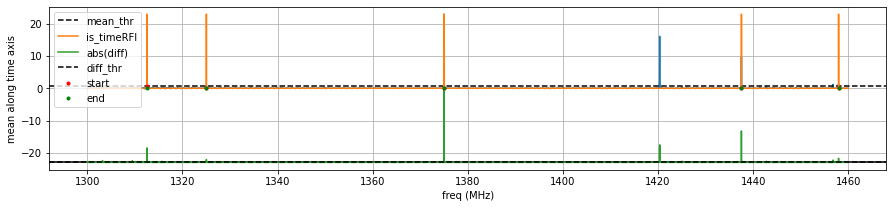

In [ ]:
narr_rfi = mask_freq_rfi(T,freq,frange = None,rtype = 'long-time',mean_times = 100,diff_times = 30,
                         ext_add=1,rfi_width_lim = [0,2],plot = True,)

In [ ]:
T[narr_rfi] = np.nan

<ipython-input-22-2eca86dad8a9>:3: RuntimeWarning: Mean of empty slice
  plt.plot(freq,np.nanmean(T[:,:],axis = 0),'.-')


(1312.0, 1313.0)

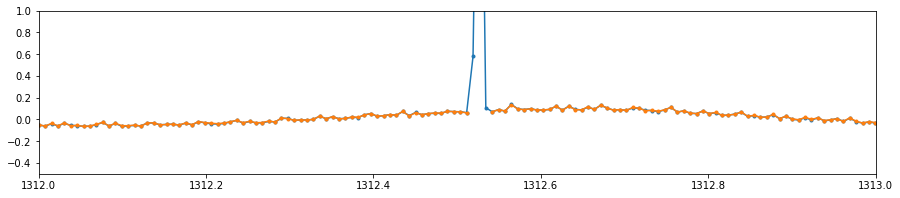

In [ ]:
plt.figure(figsize=(15,3))
plt.plot(freq,np.mean(data[:,:],axis = 0),'.-')
plt.plot(freq,np.nanmean(T[:,:],axis = 0),'.-')
plt.ylim(-.5,1)
plt.xlim(1312,1313)

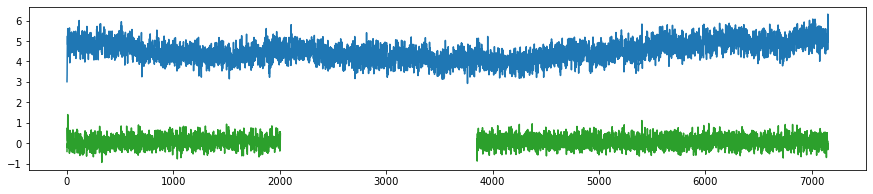

In [ ]:
fn = 1641
t = np.arange(T.shape[0])
plt.figure(figsize=(15,3))
plt.plot(t,data[:,fn])
plt.plot(t,T[:,fn])
plt.plot(t,T[:,fn+10])

两端有一些残留的RFI，不过本来数据两端也会扔掉。中间的一些与驻波混杂，目前的结果是这样。

# Result

In [ ]:
sub.plot_waterfall(T,per_vmin_max=.90,figsize=(15,5),cmap = 'plasma')

In [ ]:
name = '/data/inspur_disk01/userdir/xuc/FAST/G15/new_22/drift7/sub/G15_7_arcdrift-M12_W-20210809-specs_T-bld.hdf5'

In [ ]:
!python -m hifast.rfi $name -c ./conf/G15-2_rfi_d7.ini --outdir ./data_S/ -f

###################################Args###################################
Command Line Args:   /data/inspur_disk01/userdir/xuc/FAST/G15/new_22/drift7/sub/G15_7_arcdrift-M12_W-20210809-specs_T-bld.hdf5 -c ./conf/G15-2_rfi_d7.ini --outdir ./data_S/ -f
Config File (./conf/G15-2_rfi_d7.ini):
  rms_frange:        [1390, 1400]
  mw_frange:         [1420.2, 1420.45]
  tr:                False
  tr_n_continue:     100
  tr_times:          6.0
  tr_times_s:        1.5
  ext_add:           0
  ext_frac:          0.0
  nr:                True
  nr_mean_times:     100
  nr_diff_times:     30
  nr_mask_rms_times: 0
  pr:                True
  pr_s_sigma:        5
  pr_times:          6
  pr_times_s:        1.5
  lf:                True
  lsn_thr_type:      input_med_times
  lf_frange:         [1400, 1460]
  lf_mean_times:     2
  lf_diff_times:     0
  lf_rfi_last:       ['50', 'inf']
  lf_ext_add:        100
  lf_mask_rms_times: -1
  sf:                True
  sf_frange_step:    30
  sf_mean_times

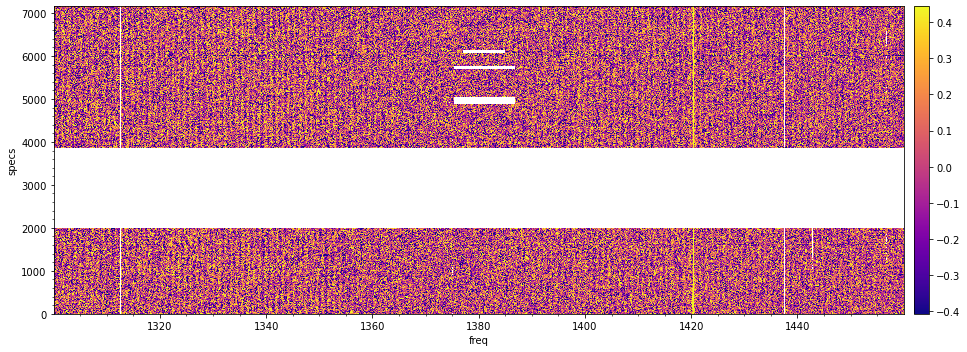

In [ ]:
ret = Read_hdf5(Args('./data_S/G15_7_arcdrift-M12_W-20210809-specs_T-bld-rfi.hdf5'))
data_ret = ret.get_data(polar='average')
is_rfi = ret.fs['is_rfi'][:]
data_ret[is_rfi] = np.nan
ret.plot_waterfall(data_ret,per_vmin_max=.90,figsize=(15,5),cmap = 'plasma')

# 扩展应用

有时我们也会遇到其他种类的RFI，改变lf/sf/nr具体的参数，也可以标记它们，下面以一个小横条和小竖条举例。

## lf / sf处理小横条

In [ ]:
subname = '/data/hw1/projects/FAST/M31/20220211/data/M31_Drift_v4_0_arcdrift-M09_W-20220211-specs_T-bld.hdf5'
sub = Read_hdf5(Args(subname))
# 合并偏振
data = sub.get_data(polar='average')[12000:14000]
freq = sub.freq

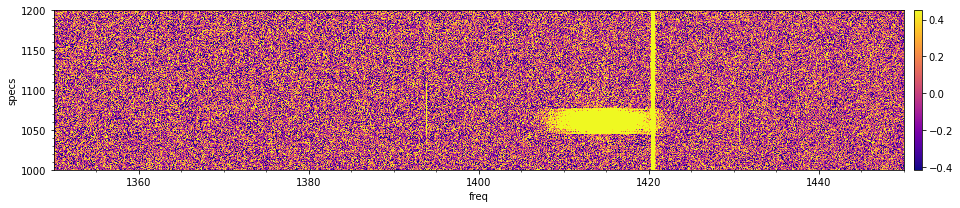

In [ ]:
sub.plot_waterfall(data,per_vmin_max=.90,figsize=(15,3),cmap = 'plasma',xylim=[1350,1450,1000,1200])

(-1.0, 8.0)

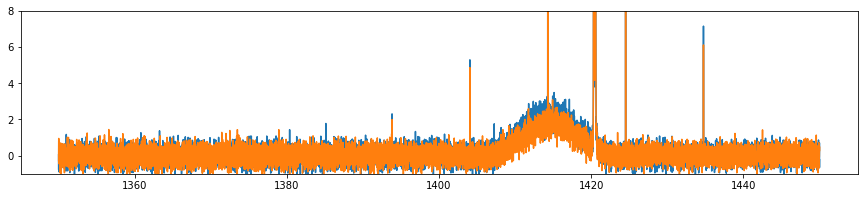

In [ ]:
data_ = sub.get_data(polar='unmerged')
tn = 13060
plt.figure(figsize=(15,3))
plt.plot(freq,data_[tn] )
plt.ylim(-1,8)

看起来pr的方法不一定能去干净，因为偏振差异不太大。看起来旁边的细RFI也是一起的。

为了排除RFI的干扰，我们仍然先保护银河系，虽然部分银河系也被污染了。

In [ ]:
mw_frange = [1420, 1421]
protect_use = (freq>mw_frange[0])&(freq<mw_frange[1])
T = deepcopy(data)
T[:,protect_use] = np.nan

### lf

rfi starts at tn = [1045], ends in tn = [1077]
After extension, rfi starts at tn = [995], ends in tn = [1127]
Median value is 0.0061081815510988235. mean_thr = 0.030540907755494118. diff_thr = 0.030540907755494118
INFO: Looking for long-freq time RFI ... [hifast.ripple.markRFI]
Mask spec with rfi above rms thr 1.0462322235107422
Found :D
Finish


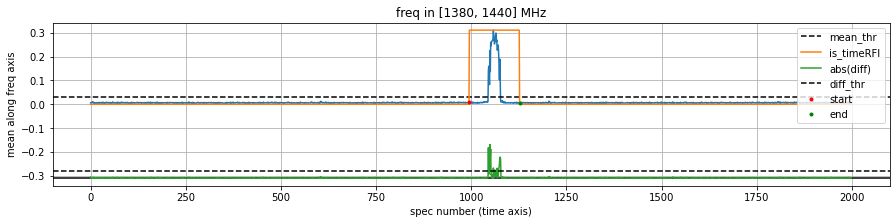

In [ ]:
l_rfi = mask_time_rfi(T,freq, rtype = 'long-freq',frange =[1380,1440],mean_times = 5,diff_times = 5,
                      ext_add=50,rfi_width_lim = [10,50],plot = True,rms_frange=[1390,1400],mask_rms_times=4)

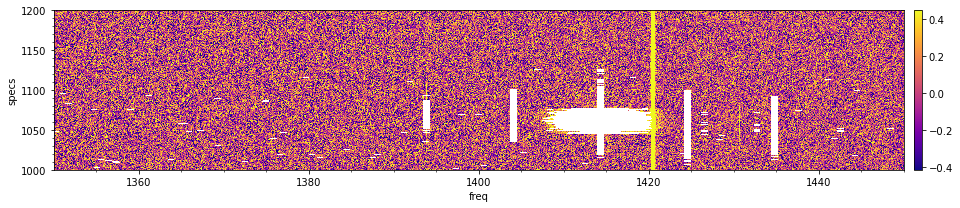

In [ ]:
T2 = deepcopy(data)
T2[l_rfi] = np.nan

sub.plot_waterfall(T2,per_vmin_max=.90,figsize=(15,3),cmap = 'plasma',xylim=[1350,1450,1000,1200])

有一些RFI残余。。。如果已知RFI范围，也可以扔掉一个矩形

rfi starts at tn = [1045], ends in tn = [1077]
After extension, rfi starts at tn = [1035], ends in tn = [1087]
Median value is 0.0061081815510988235. mean_thr = 0.030540907755494118. diff_thr = 0.030540907755494118
INFO: Looking for long-freq time RFI ... [hifast.ripple.markRFI]
Mask spec with rfi in input freq range [1380, 1440]
Found :D
Finish


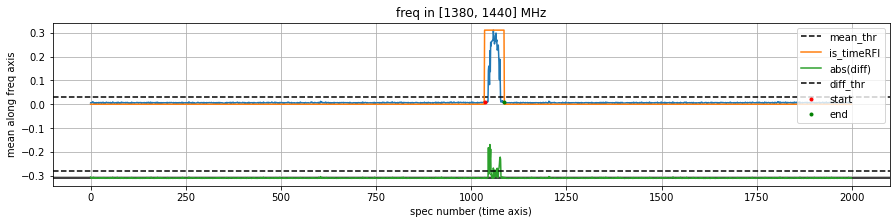

In [ ]:
l_rfi = mask_time_rfi(T,freq, rtype = 'long-freq',frange =[1380,1440],mean_times = 5,diff_times = 5,
                      ext_add=10,rfi_width_lim = [10,50],plot = True,rms_frange=[1390,1400],mask_rms_times=0)

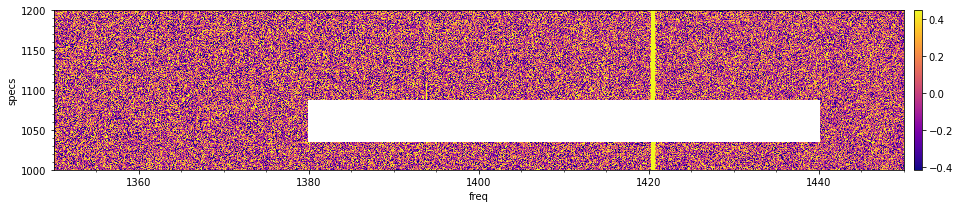

In [ ]:
T2 = deepcopy(data)
T2[l_rfi] = np.nan

sub.plot_waterfall(T2,per_vmin_max=.90,figsize=(15,3),cmap = 'plasma',xylim=[1350,1450,1000,1200])

### sf
sf用于sinc函数型，但是这个只有一个峰。

rfi starts at tn = [1045], ends in tn = [1077]
Median value is 0.0061081815510988235. mean_thr = 0.030540907755494118. diff_thr = 0.0
INFO: Looking for short-freq time RFI in [1380, 1440] ... [hifast.ripple.markRFI]
tn = [1044, 1078] mask frange: [1398.06747437 1435.14633179]
Found :D
Finish


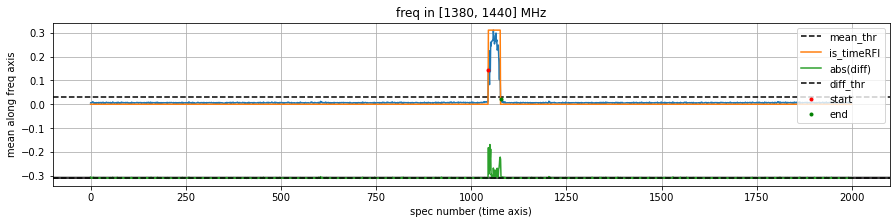

In [ ]:
s_rfi = mask_time_rfi(T,freq, rtype = 'short-freq',frange =[1380,1440],mean_times = 5,diff_times = 0,
                      ext_add=0,rfi_width_lim = [10,50],plot = True,rms_frange=[1390,1400],mask_rms_times=3)

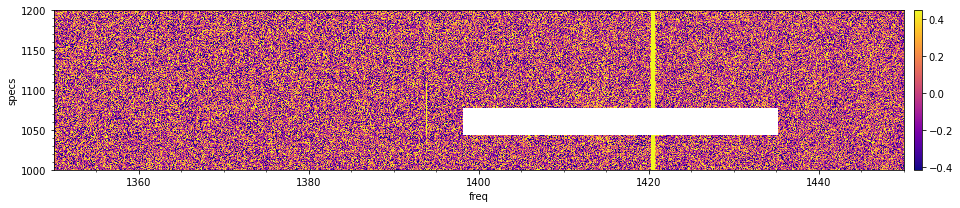

In [ ]:
T2 = deepcopy(data)
T2[s_rfi] = np.nan

sub.plot_waterfall(T2,per_vmin_max=.90,figsize=(15,3),cmap = 'plasma',xylim=[1350,1450,1000,1200])

虽然细线还在，但是也还可以。

## nr处理小竖条

In [ ]:
subname = '/data/hw1/projects/FAST/M31/20220131/data/M31_Drift_v4_61_arcdrift-M01_W-20220131-specs_T-bld.hdf5'
sub = Read_hdf5(Args(subname))

data = sub.get_data(polar='average')
freq = sub.freq

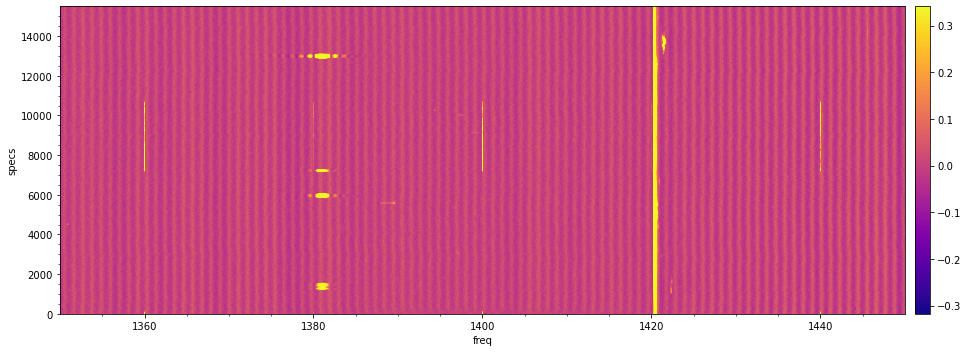

In [ ]:
sub.plot_waterfall(data,per_vmin_max=.90,figsize=(15,5),cmap = 'plasma',interp_method='gaussian')

(-1.0, 4.0)

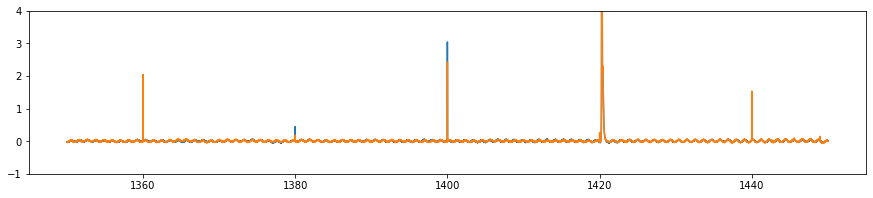

In [ ]:
data_ = sub.get_data(polar='unmerged')
plt.figure(figsize=(15,3))
plt.plot(freq,np.mean(data_[8000:10000],axis = 0) )
plt.ylim(-1,4)

而且20MHz间隔。如果觉得用nr完全扔掉整个通道可惜，可以：

INFO: Looking for long-time narrowband freq RFI ... [hifast.ripple.markRFI]
rfi starts at tn = [ 1310  3931  3995  4153  4158  4163  6552 11795 12968], ends in tn = [ 1311  3932  3996  4154  4159  4164  6553 11796 12969]
After extension, rfi starts at tn = [ 1309  3930  4152  6551 11794 12967], ends in tn = [ 1312  3933  4155  6554 11797 12970]
Median value is 0.0036656700540333986. mean_thr = 0.07331340108066797. diff_thr = 0.018328350270166993
Mask channels with rfi above rms thr 0.5942688882350922
Found :D
Finish


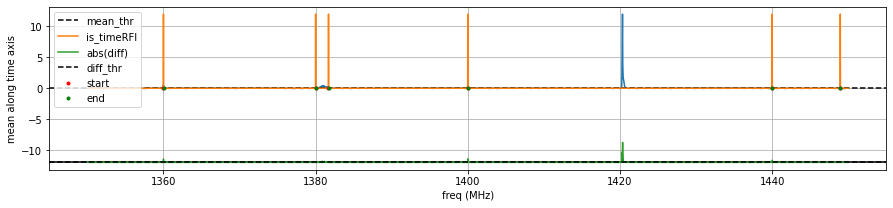

In [ ]:
narr_rfi = mask_freq_rfi(data,freq,frange = None,rtype = 'long-time',mean_times = 20,diff_times = 5,
                         ext_add=1,rfi_width_lim = [0,2],plot = True,rms_frange = [1390,1400],mask_rms_times=3)

(1359.0, 1361.0)

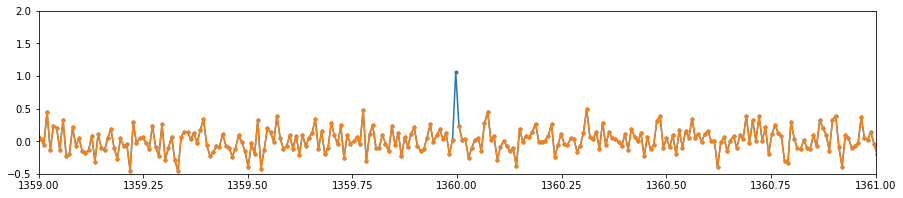

In [ ]:
T2 = deepcopy(data)
T2[narr_rfi] = np.nan
tn = 9000
plt.figure(figsize=(15,3))
plt.plot(freq,data[tn,:],'.-')
plt.plot(freq,T2[tn,:],'.-')
plt.ylim(-.5,2)
plt.xlim(1359,1361)

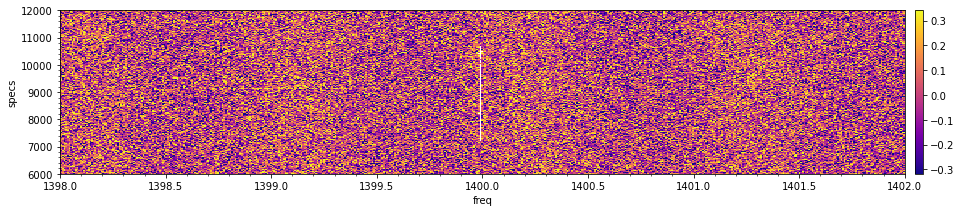

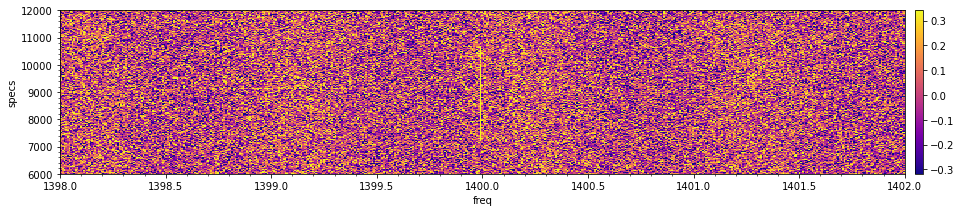

In [ ]:
sub.plot_waterfall(T2,per_vmin_max=.90,figsize=(15,3),cmap = 'plasma',xylim=(1398,1402,6000,12000),)
sub.plot_waterfall(data,per_vmin_max=.90,figsize=(15,3),cmap = 'plasma',xylim=(1398,1402,6000,12000),)

# pdr
由于2021年7月后的数据中已经没有8.1MHz的周期RFI，所以这里只是简单演示。

In [ ]:
subname = './data_S/G15_drift_6_arcdrift-M04_W-20200605-specs_T-bld.hdf5'
sub = Read_hdf5(Args(subname))
data = sub.get_data(polar='average')
freq = sub.freq

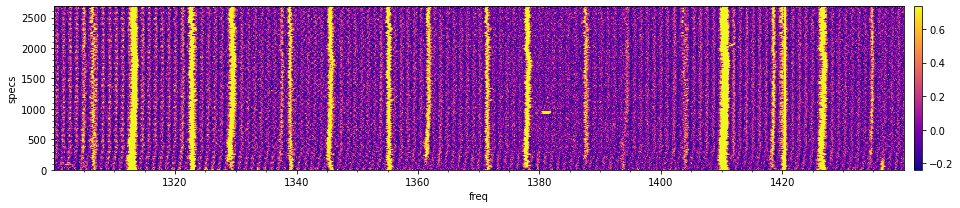

In [ ]:
sub.plot_waterfall(data,per_vmin_max=.90,figsize=(15,3),cmap = 'plasma')

先标记sf

rfi starts at tn = [ 83 924], ends in tn = [108 962]
Median value is 0.006943073123693466. mean_thr = 0.0208292193710804. diff_thr = 0.06943073123693466
INFO: Looking for short-freq time RFI in [1379.5, 1383] ... [hifast.ripple.markRFI]
tn = [923, 963] mask frange: [1379.50515747 1382.99942017]
Found :D
Finish


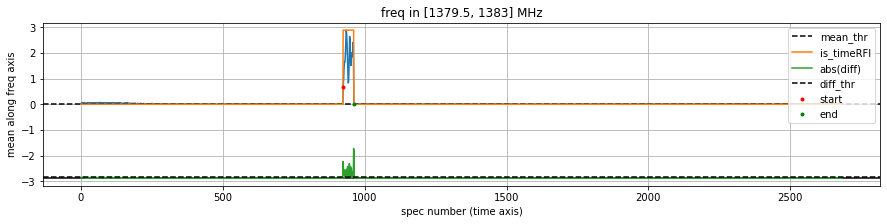

In [ ]:
s_rfi = mask_time_rfi(data,freq, rtype = 'short-freq',frange =[1379.5,1383],mean_times = 3,diff_times = 10,
                      ext_add=0,rfi_width_lim = 20,plot = True,rms_frange=[1390,1400])

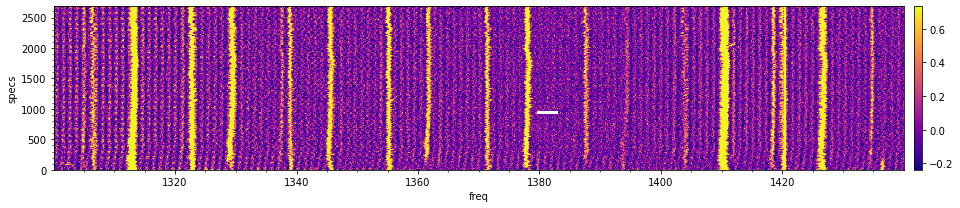

In [ ]:
T = deepcopy(data)
T[s_rfi] = np.nan
sub.plot_waterfall(T,per_vmin_max=.90,figsize=(15,3),cmap = 'plasma')

进行平滑

In [ ]:
sm_kwargs = {}
sm_kwargs['s_method_t'] = 'boxcar'
sm_kwargs['s_sigma_t'] = 7
sm_kwargs['s_method_freq'] = 'gaussian' 
sm_kwargs['s_sigma_freq'] = 3
sm_kwargs['is_rfi'] = s_rfi
T = do_smooth(data,**sm_kwargs)

Smoothing t ...
Smoothing freq ...


他们是因为馈源仓外有三台压缩机，在数据里体现为两到三组周期间隔的高斯型RFI，如下面的谱线

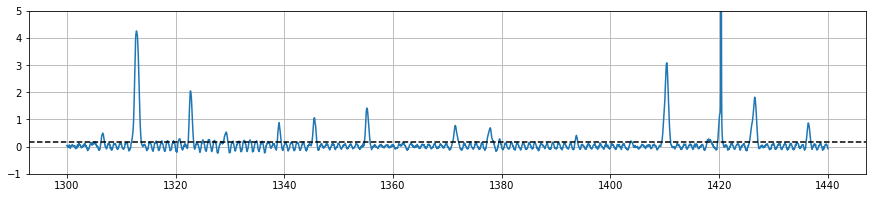

In [ ]:
tn = 10
spec = deepcopy(T[tn,:])

RMS = real_rms(spec,freq,6,[1390,1400])
thr = 15*RMS # rms_thr

plt.figure(figsize=(15,3))
plt.plot(freq,spec)
plt.axhline(thr,linestyle = '--',color = 'k')
plt.grid()
plt.ylim(-1,5)

mw_range = [1419,1425] # 给大一点，防止标记信号
protect_use = (freq>mw_range[0])&(freq<mw_range[1])
is_rfi = (spec>thr)&(~protect_use)

rfi.py中对应的参数设置

| --pdr para | 建议 |
|---|---|
|--rfi_thr | 大于rms rfi_thr倍的会被记为rfi。根据是否平滑选择阈值
|--rms_frange | 用于计算rms的干净频率区间，很难找，所以自动的会不准
|--mw_frange | 一个大致可能存在信号的区间，先保护起来，后面不会用它预估rfi位置
|--rfi_groups | rfi的形态呈现为8.1MHz间隔的几组，分类进行更精确的拟合。'two_groups','three_groups','all'
|--rfi_width_lim | 粗找rfi区域时，其宽度应该大于的通道数。太细的可能是驻波，可能是点源，排除
|--ext_sec | 粗找到rfi后，扩充边界的通道数
|--freq_thr | 对粗测的rfi中心分类时，可以偏离预计中心一段频率。
|--freq_step | 对粗测的rfi中心分类时，预计中心的间隔大约为8.1MHz。

分类后进行直线拟合，得到rfi的精确分布。如果大于rfi_thr的区域落在rfi精确理论频率上，则被标记为真rfi，可以防止高流量的源被标记。

标记方法提供了两种

| --pdr para | 建议 |
|---|---|
|--mask_RFI_method | 'fixed freq' 对于小rfi，固定mask宽度；'2 sides' 从中心向两边按step循环，确定mask边界，比较慢
|--ext_edge| 结果扩展边缘的通道数
|--mask_thr| 只mask超过rms的几倍的峰值。很小的rfi会保留。
|**'fixed freq'** ||
|--mask_all_theory| 是否理论的全mask，这样会非常干净
|--freq_from_theory| 很小的去掉多少频率(固定宽度MHz)
|**'2 sides'**|| 
|--small_rfi_times| 小于RMS这个倍数的不标记，不然会标记太多
|--chan_step| step通道数
|--freq_from_theory| mask rfi最大的宽度|

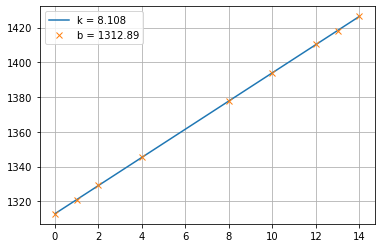

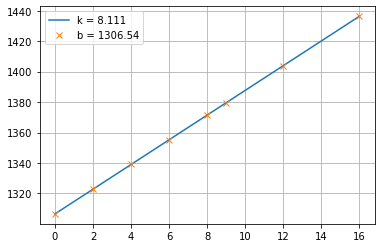

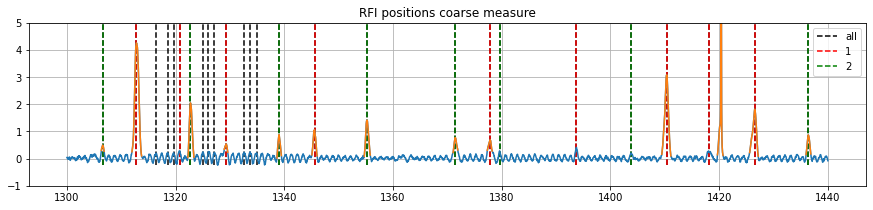

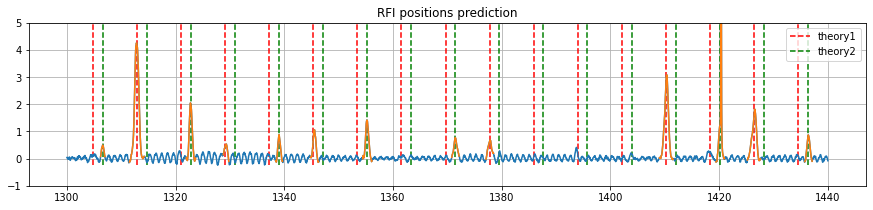

In [ ]:
pd_rfi,theory = find_RFI(spec,freq,is_rfi ,ext_edge=2,plot =True,ylim=(-1,5),
                rfi_width_lim=20,ext_sec = 20,RMS=RMS,rfi_groups='two_groups',freq_thr = .7,mask_thr=40,
                freq_from_theory =.5,mask_RFI_method = 'fixed_freq')

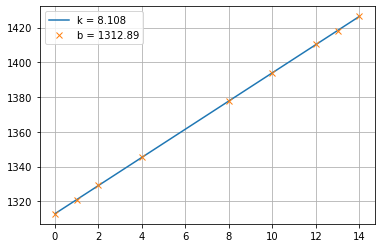

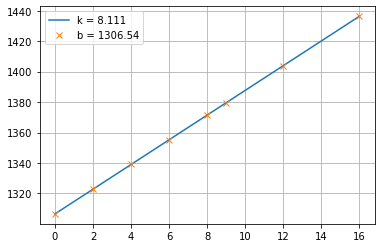

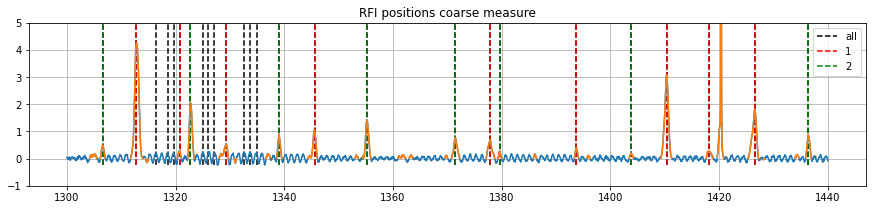

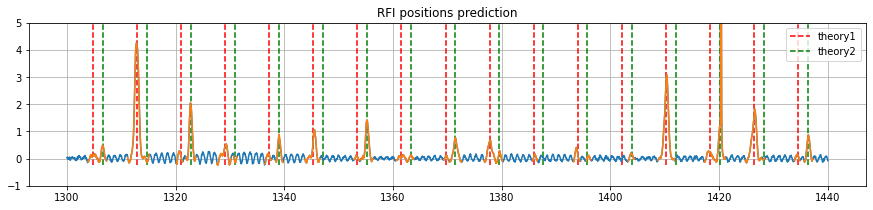

In [ ]:
pd_rfi,theory = find_RFI(spec,freq,is_rfi ,ext_edge=2,plot =True,ylim=(-1,5),
                rfi_width_lim=20,ext_sec = 20,RMS=RMS,rfi_groups='two_groups',freq_thr = .7,mask_thr=15,
                mask_RFI_method='2_sides',freq_from_theory=3,small_rfi_times=2,chan_step = 1)

In [ ]:
name = './data_S/G15_drift_6_arcdrift-M04_W-20200605-specs_T-bld.hdf5'

In [ ]:
!python -m hifast.rfi $name -c ./conf/G15-rfi_old.ini --outdir ./data_S/ -f

###################################Args###################################
Command Line Args:   ./data_S/G15_drift_6_arcdrift-M04_W-20200605-specs_T-bld.hdf5 -c ./conf/G15-rfi_old.ini --outdir ./data_S/ -f
Config File (./conf/G15-rfi_old.ini):
  rms_frange:        [1390, 1400]
  mw_frange:         [1420.2, 1420.45]
  tr:                False
  tr_n_continue:     100
  tr_times:          6.0
  tr_times_s:        1.5
  ext_add:           0
  ext_frac:          0.0
  nr:                False
  nr_mean_times:     100
  nr_diff_times:     30
  pr:                True
  pr_s_sigma:        5
  pr_times:          6
  pr_times_s:        1.5
  lf:                False
  lsn_thr_type:      input_med_times
  lf_frange:         [1400, 1460]
  lf_mean_times:     2
  lf_diff_times:     0
  lf_rfi_last:       50
  lf_ext_add:        100
  sf:                True
  sf_frange:         [1379.5, 1383]
  sf_mean_times:     3
  sf_diff_times:     10
  sf_rfi_last:       20
  sf_ext_add:        0

##########

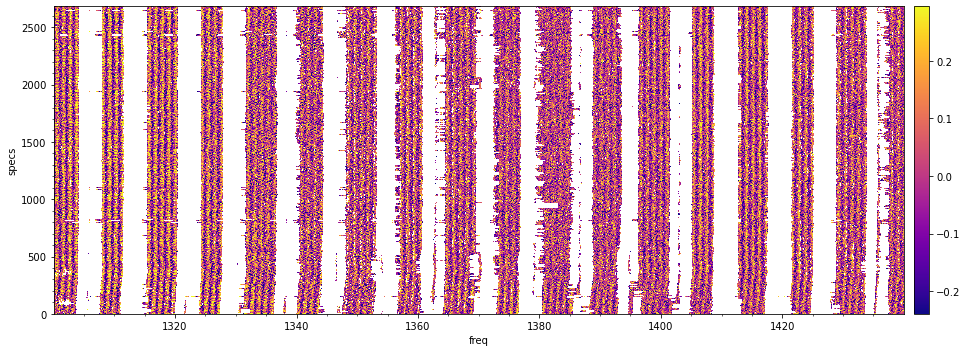

In [ ]:
ret = Read_hdf5(Args('./data_S/G15_drift_6_arcdrift-M04_W-20200605-specs_T-bld-rfi.hdf5'))
data_ret = ret.get_data(polar='average')
is_rfi = ret.fs['is_rfi'][:]
data_ret[is_rfi] = np.nan
ret.plot_waterfall(data_ret,per_vmin_max=.90,figsize=(15,5),cmap = 'plasma')

只是这样扔的比较多。。。